## **Setup**

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats

warnings.filterwarnings('ignore')

file_path = '/kaggle/input/zara-fashion-sales-dataset-and-report/Zara_Sales_Analysis.csv'
fashion = pd.read_csv(file_path, delimiter=';', encoding='utf-8')
fashion.info()
fashion.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

0

## **Revenue Breakdown** 

**Total Revenue and Best-Selling Products**

In [2]:
fashion['revenue_per'] = fashion['price'] * fashion['Sales Volume']
total_revenue = fashion['revenue_per'].sum()
total_m = total_revenue / 1000000

print(f"Total Revenue: $ {total_m:.2f}M\n")

top_revenue = (
    fashion.groupby('name', as_index = False)['revenue_per']
    .sum()
    .sort_values(by = 'revenue_per', ascending = False)
    .head(10)
)

top_revenue['Revenue ($ M)'] = (top_revenue['revenue_per'] / 1000000).round(2)
top_revenue = top_revenue.rename(columns = {'name': 'Product Name'})

print("Top Products by Revenue:\n")
print(top_revenue[['Product Name', 'Revenue ($ M)']].to_string(index = False))

Total Revenue: $ 38.99M

Top Products by Revenue:

                        Product Name  Revenue ($ M)
   CONTRASTING PATCHES BOMBER JACKET           0.89
           SUIT JACKET IN 100% LINEN           0.82
          FAUX LEATHER BOMBER JACKET           0.80
                     PLAID OVERSHIRT           0.70
                   RIB COLLAR JACKET           0.69
                SLIM FIT SUIT JACKET           0.68
                    POCKET OVERSHIRT           0.67
VINTAGE EFFECT LEATHER BOMBER JACKET           0.65
                        SUEDE JACKET           0.65
              BOUCLÉ TEXTURED JACKET           0.61


In [3]:
def sales_sum(df, group_col):
    summary = (
        df.groupby(group_col, as_index = False)
        .agg({
            'revenue_per': 'sum',
            'Sales Volume': 'sum'
        })
        .sort_values(by = 'revenue_per', ascending = False))
    
    summary['Revenue ($ M)'] = (summary['revenue_per'] / 1000000).round(2)
    
    print(f"Sales by {group_col}:\n")
    print(summary[[group_col, 'Sales Volume', 'Revenue ($ M)']].to_string(index=False))
    
    return summary

**Sales by Product Category**

In [4]:
fashion = fashion.rename(columns={'terms': 'Category'})
revenue_cat = sales_sum(fashion, 'Category')

Sales by Category:

Category  Sales Volume  Revenue ($ M)
 jackets        259468          26.58
sweaters         75242           4.09
   shoes         57906           3.75
t-shirts         53637           3.70
   jeans         13320           0.86


**Sales by In-Store Product Position**

In [5]:
revenue_pos = sales_sum(fashion, 'Product Position')

Sales by Product Position:

Product Position  Sales Volume  Revenue ($ M)
           Aisle        177396          15.48
         End-cap        152930          12.55
  Front of Store        129247          10.96


**Sales by Promotion**

In [6]:
revenue_promo = sales_sum(fashion, 'Promotion')

Sales by Promotion:

Promotion  Sales Volume  Revenue ($ M)
      Yes        219261          19.99
       No        240312          18.99


**Sales by Seasonal**

In [7]:
revenue_season = sales_sum(fashion, 'Seasonal')

Sales by Seasonal:

Seasonal  Sales Volume  Revenue ($ M)
     Yes        233181          19.83
      No        226392          19.16


## **Revenue Share**

In [8]:
def revenue_pie(ax, df, label_col, title):
    ax.pie(
        df['revenue_per'],
        labels = df[label_col],
        autopct = '%1.1f%%',
        startangle = 90,
        textprops = {'fontsize': 9}
    )
    ax.set_title(title, fontsize = 12)

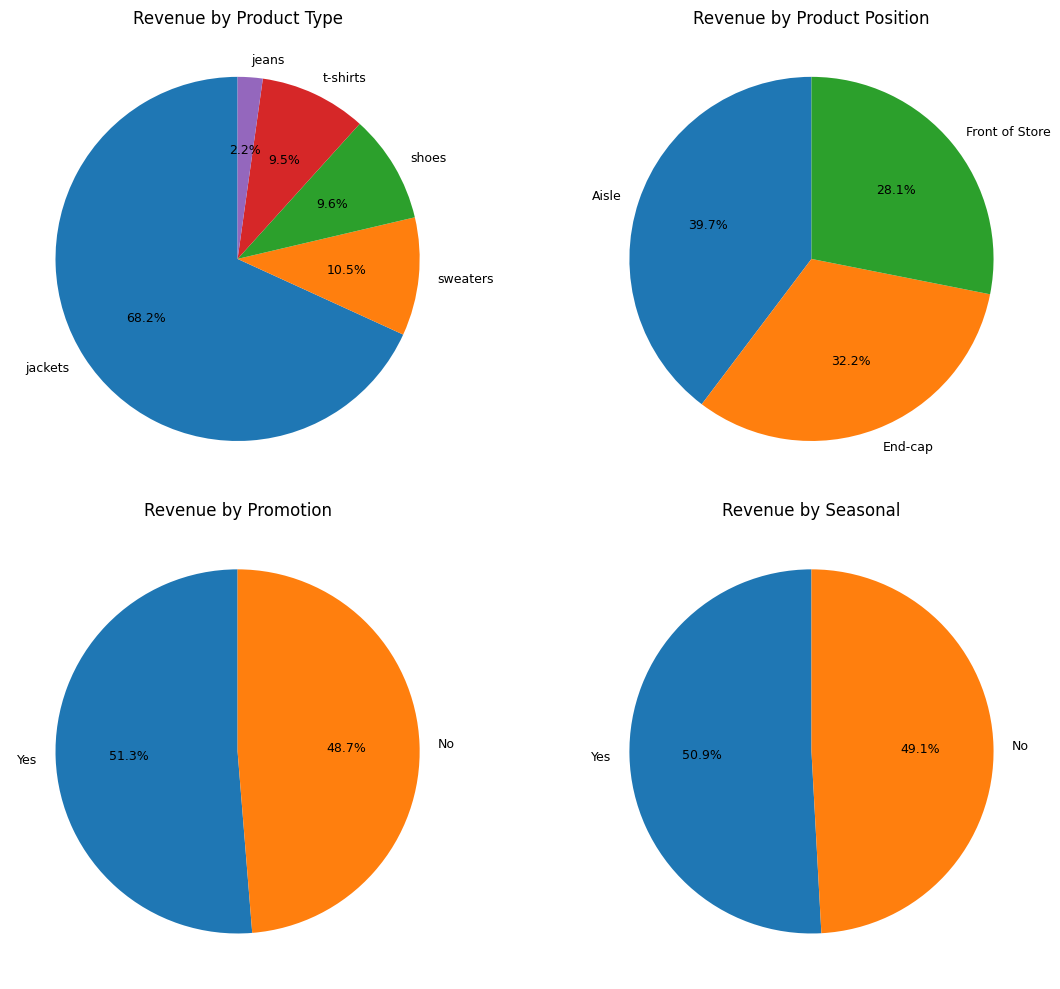

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() 

revenue_pie(axes[0], revenue_cat, 'Category', 'Revenue by Product Type')
revenue_pie(axes[1], revenue_pos, 'Product Position', 'Revenue by Product Position')
revenue_pie(axes[2], revenue_promo, 'Promotion', 'Revenue by Promotion')
revenue_pie(axes[3], revenue_season, 'Seasonal', 'Revenue by Seasonal')

plt.tight_layout()
plt.show()

## **Prediction Model for Maximizing Sales Volume**

In [10]:
fashion['Promotion'] = fashion['Promotion'].astype('category')
fashion['Product Category'] = fashion['Product Category'].astype('category')
fashion['Seasonal'] = fashion['Seasonal'].astype('category')
fashion ['Product Position'] = fashion['Product Position'].astype('category')

fashion = fashion.rename(columns = {'Product Position': 'Product_Position',
                                   'Sales Volume': 'Sales_Volume'})
fashion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Product ID        252 non-null    int64   
 1   Product_Position  252 non-null    category
 2   Promotion         252 non-null    category
 3   Product Category  252 non-null    category
 4   Seasonal          252 non-null    category
 5   Sales_Volume      252 non-null    int64   
 6   brand             252 non-null    object  
 7   url               252 non-null    object  
 8   sku               252 non-null    object  
 9   name              251 non-null    object  
 10  description       250 non-null    object  
 11  price             252 non-null    float64 
 12  currency          252 non-null    object  
 13  scraped_at        252 non-null    object  
 14  Category          252 non-null    object  
 15  section           252 non-null    object  
 16  revenue_per       252 non-

**Log-Linear Prediction Model**

In [11]:
fashion['log_Sales_Volume'] = np.log1p(fashion['Sales_Volume'])
log_model = smf.ols('log_Sales_Volume ~ Promotion * Seasonal * Product_Position', data = fashion).fit()
log_anova = sm.stats.anova_lm(log_model, typ = 2)

print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_Sales_Volume   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.6144
Date:                Sun, 08 Feb 2026   Prob (F-statistic):              0.816
Time:                        00:34:54   Log-Likelihood:                -151.91
No. Observations:                 252   AIC:                             327.8
Df Residuals:                     240   BIC:                             370.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [12]:
print(log_anova)

                                        sum_sq     df         F    PR(>F)
Promotion                             0.005910    1.0  0.028790  0.865407
Seasonal                              0.004618    1.0  0.022495  0.880903
Product_Position                      0.056576    2.0  0.137809  0.871334
Promotion:Seasonal                    0.021221    1.0  0.103380  0.748090
Promotion:Product_Position            0.471588    2.0  1.148706  0.318784
Seasonal:Product_Position             0.294830    2.0  0.718154  0.488697
Promotion:Seasonal:Product_Position   0.514668    2.0  1.253639  0.287326
Residual                             49.264676  240.0       NaN       NaN


**Checking Assumptions**

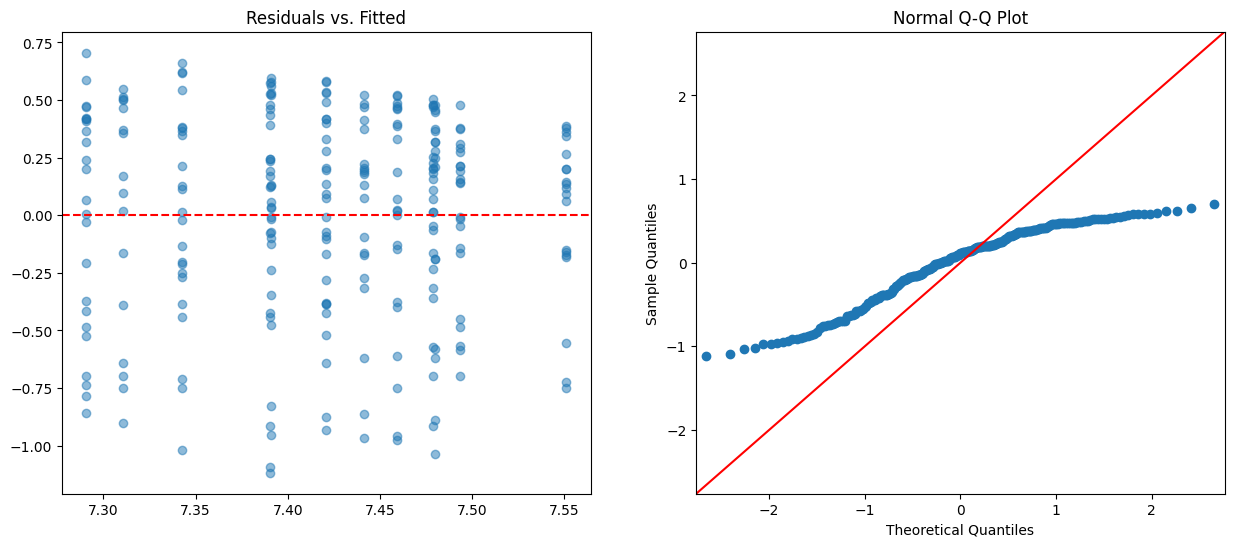

In [13]:
log_residuals = log_model.resid
log_fitted = log_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize = (15, 6))

axes[0].scatter(log_fitted, log_residuals, alpha=0.5)
axes[0].axhline(y=0, color = 'red', linestyle = '--')
axes[0].set_title('Residuals vs. Fitted')

sm.qqplot(log_residuals, line = '45', ax = axes[1])
axes[1].set_title('Normal Q-Q Plot')

plt.show()

**Interaction Plots**

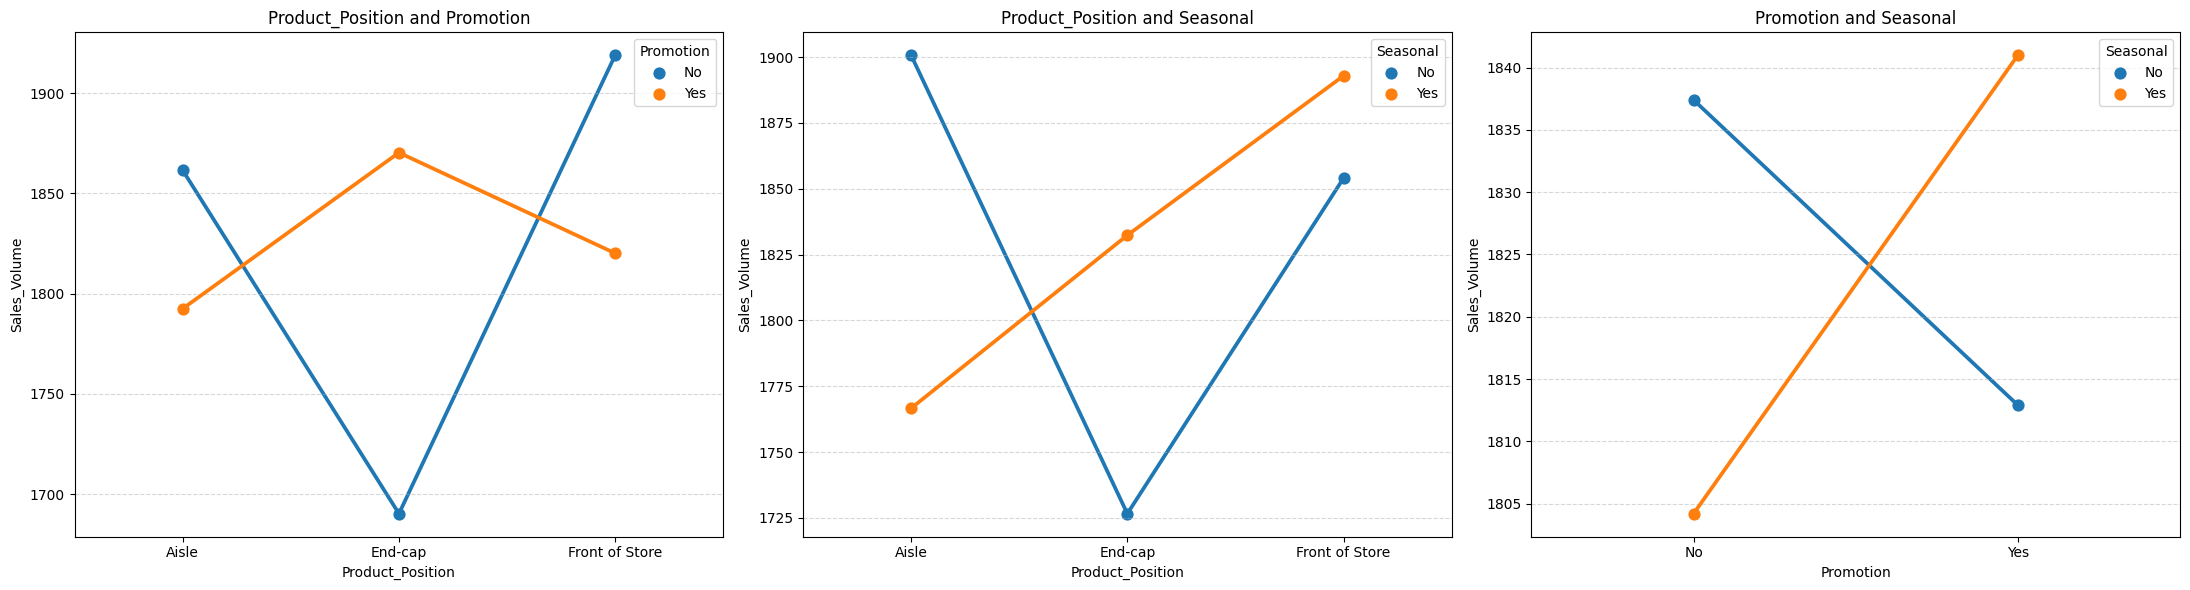

In [14]:
def interaction_plot(df, x_col, hue_col, ax, y_col='Sales_Volume'):
    sns.pointplot(
        data = df, 
        x = x_col, 
        y = y_col, 
        hue = hue_col, 
        errorbar = None, 
        ax = ax
    )
    ax.set_title(f'{x_col} and {hue_col}', fontsize = 12)
    ax.grid(axis = 'y', linestyle = '--', alpha = 0.5)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

interaction_plot(fashion, 'Product_Position', 'Promotion', axes[0])
interaction_plot(fashion, 'Product_Position', 'Seasonal', axes[1])
interaction_plot(fashion, 'Promotion', 'Seasonal', axes[2])

plt.tight_layout()
plt.show()

**Prediction for Maximizing Sales Volume**

In [15]:
grid = pd.MultiIndex.from_product(
    [fashion['Product_Position'].unique(), 
     fashion['Promotion'].unique(), 
     fashion['Seasonal'].unique()],
    names=['Product_Position', 'Promotion', 'Seasonal']
).to_frame(index = False)

grid['Predicted_Vol'] = np.exp(log_model.predict(grid))
best = grid.loc[[grid['Predicted_Vol'].idxmax()]]

print("The Optimal Condition for Maximum Sales Volume:")
print(best.to_string(index = False))

The Optimal Condition for Maximum Sales Volume:
Product_Position Promotion Seasonal  Predicted_Vol
  Front of Store        No       No    1902.979312
